<a href="https://colab.research.google.com/github/alyssaplayer/BU_OMDS_APlayerRepo/blob/main/Mod6_ExpDesign/Mod_6_ExpDesign_CodingQuizzes%205-8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###DX702: Experimental Design and Causality
#Weekly Coding Quizzes - Weeks 5-8


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#### Week 5


In [2]:
#Generate the Data
# Code to create data for this question
num = 100000

difficulty = np.random.uniform(0, 1, (num,))

speed = np.maximum(np.random.normal(15, 5, (num, )) - difficulty * 10, 0)

accident = np.minimum(np.maximum(0.03 * speed + 0.4 * difficulty + np.random.normal(0, 0.3, (num,)), 0), 1)

df = pd.DataFrame({'difficulty': difficulty, 'speed': speed, 'accident': accident})

Q5.1: Use X to predict Y many times via regression with different data sets. Use many samples in each prediction. Which is closest to the average coefficient of X if you do the experiment enough times.

In [3]:
!pip install statsmodels

In [4]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

num_experiments = 500 # doing less so it doesn't take as long
sample_size = 10000
coefficients = []

for i in range(num_experiments):
    difficulty = np.random.uniform(0, 1, (sample_size,))
    speed = np.maximum(np.random.normal(15, 5, (sample_size,)) - difficulty * 10, 0)

    #x(difficulty) predicts y(speed)
    X = sm.add_constant(difficulty)
    model = sm.OLS(speed, X).fit()

    # extract coefficients from 500 loops and store to calculate the mean
    coefficients.append(model.params[1])

print(np.mean(coefficients))

-9.653019296346342


Q5.2: Then use X and Z to predict Y many times via regression with different datasets. Which of these is closest to the average coefficient of X? In practice, should we run such a regression? We are controlling for Z but Z is a collider. That is, Y and X both cause Z. Should we control for it or are we better off ignoring Z? Why or why not?

In [5]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

num_experiments = 500 # doing less so it doesn't take as long
sample_size = 10000
coefficients = []

for i in range(num_experiments):
    difficulty = np.random.uniform(0, 1, (sample_size,))
    speed = np.maximum(np.random.normal(15, 5, (sample_size,)) - difficulty * 10, 0)
    accident = np.minimum(np.maximum(0.03 * speed + 0.4 * difficulty + np.random.normal(0, 0.3, (sample_size,)), 0), 1)


    #x(difficulty) and z (accident) predicts y(speed)
    X = sm.add_constant(np.column_stack((difficulty, accident)))
    model = sm.OLS(speed, X).fit()

    # extract coefficients from 500 loops and store to calculate the mean
    coefficients.append(model.params[1])

print(np.mean(coefficients))

-10.321475776534786


###Weekly Reflection 5:
Write a dataset that simulates this situation:
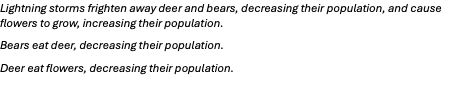


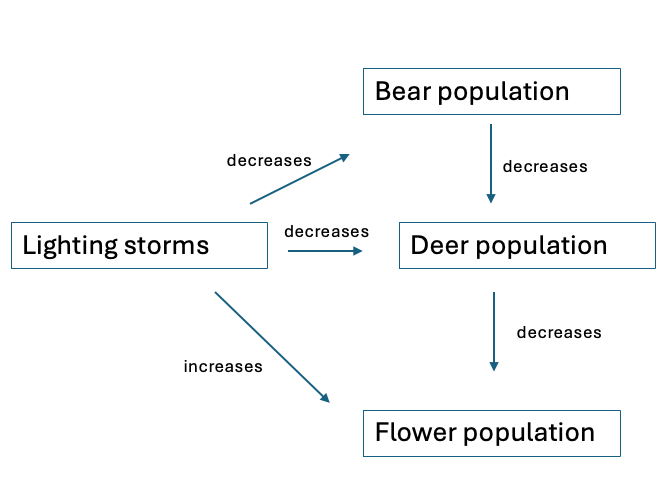

In [6]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 500  # number of observed time periods (e.g. days)

#lighting storms are the origin,
storm = np.random.poisson(lam=3, size=n)

#bear populations decreases with storm
bear_baseline = 20
bear = bear_baseline - 2 * storm + np.random.normal(0, 2, n)

#deer population decreases with storm AND bear
deer_baseline = 50
deer = deer_baseline - 2 * storm - 0.5 * bear + np.random.normal(0, 3, n)

#flower population increases with storm AND decreases with bear
flower_baseline = 200
flower = flower_baseline + 5 * storm - 0.8 * deer + np.random.normal(0, 10, n)

# populations can't go negative -> only to 0
bear = np.clip(bear, 0, None)
deer = np.clip(deer, 0, None)
flower = np.clip(flower, 0, None)

df = pd.DataFrame({
    'storm': storm,
    'bear': bear,
    'deer': deer,
    'flower': flower
})

df.head()


,storm,bear,deer,flower
0,4,12.281772,38.280482,194.111936
1,1,14.463121,37.847801,165.457948
2,3,14.646335,38.105906,190.070402
3,3,13.704795,38.664013,174.881924
4,2,15.067927,41.646666,172.508999


#Week 6

In [7]:

import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors

df = pd.read_csv('homework_6.1.csv')

treated = df[df['X'] == 1].reset_index(drop=True)
untreated = df[df['X'] == 0].reset_index(drop=True)


def nearest_match(query_z, source_z, source_y):

    nn = NearestNeighbors(n_neighbors=1).fit(source_z[['Z']])
    _, idx = nn.kneighbors(query_z[['Z']])
    return source_y.values[idx.ravel()]


# Each treated row matched to its nearest untreated counterfactual
cf_treated = nearest_match(treated, untreated, untreated['Y'])
effects_treated = treated['Y'].values - cf_treated

# Each untreated row matched to its nearest treated counterfactual
cf_untreated = nearest_match(untreated, treated, treated['Y'])
effects_untreated = cf_untreated - untreated['Y'].values

ate = np.concatenate([effects_treated, effects_untreated]).mean()
att = effects_treated.mean()
atu = effects_untreated.mean()
ote = effects_untreated.max()

print(f"ATE  (avg treatment effect):             {ate:.3f}")
print(f"ATT  (avg treatment effect on the treated):   {att:.3f}")
print(f"ATU  (avg treatment effect on the untreated):  {atu:.3f}")
print(f"OTE  (optimal treatment effect):              {ote:.3f}")

FileNotFoundError: [Errno 2] No such file or directory: 'homework_6.1.csv'

In [ ]:
print(f"OTE original  (optimal treatment effect): {ote:.3f}")
ote_90 = np.percentile(effects_untreated, 90)
print(f"OTE_90: {ote_90:.3f}")

ote_95 = np.percentile(effects_untreated, 95)
print(f"OTE_95: {ote_95:.3f}")

ote_99 = np.percentile(effects_untreated, 99)
print(f"OTE_99: {ote_99:.3f}")

ote_80 = np.percentile(effects_untreated, 80)
print(f"OTE_80: {ote_80:.3f}")

#Week 7

In [8]:
#Question 1:
import numpy as np
import statsmodels.api as sm

np.random.seed(0)
n = 1000
W = np.random.normal(0, 1, n)
X = W + np.random.normal(0, 1, n)
Z = np.random.normal(0, 1, n)
Y = X + Z + W + np.random.normal(0, 1, n)

#
X1 = sm.add_constant(np.column_stack([X, Z, W]))
model1 = sm.OLS(Y, X1).fit()
resid1 = model1.resid
print("corr(X, error) W model:", np.corrcoef(X, resid1)[0, 1])



corr(X, error) W model: -1.2758844705045305e-15


In [9]:
# Question 2
X2 = sm.add_constant(np.column_stack([X, Z]))
model2 = sm.OLS(Y, X2).fit()
resid2 = model2.resid
print("corr(X, error) W absorbed", np.corrcoef(X, resid2)[0, 1])

corr(X, error) W absorbed -2.137537272050016e-15


In [10]:
import pandas as pd
df = pd.read_csv("homework_7.1.csv")

for w_val in [-1, 0, 1]:
    subset = df[np.abs(df["W"] - w_val) < 0.25]
    Xs = sm.add_constant(subset[["X", "Z"]])
    m = sm.OLS(subset["Y"], Xs).fit()
    print(f"W ≈ {w_val}: coef on X = {m.params['X']:.3f}  (n={len(subset)})")

df["XW"] = df["X"] * df["W"]
Xi = sm.add_constant(df[["X", "Z", "W", "XW"]])
mi = sm.OLS(df["Y"], Xi).fit()
b_X, b_XW = mi.params["X"], mi.params["XW"]
for w_val in [-1, 0, 1]:
    print(f"W = {w_val}: implied coef on X = {b_X + b_XW*w_val:.3f}")

W ≈ -1: coef on X = 0.902  (n=1221)
W ≈ 0: coef on X = 1.418  (n=1962)
W ≈ 1: coef on X = 1.920  (n=1124)
W = -1: implied coef on X = 0.900
W = 0: implied coef on X = 1.396
W = 1: implied coef on X = 1.893


In [11]:
#question 4
def make_error(corr_const, num):
    err = list()
    prev = np.random.normal(0, 1)
    for n in range(num):
        prev = corr_const * prev + (1 - corr_const) * np.random.normal(0, 1)
        err.append(prev)
    return np.array(err)

def run_trial(corr_const, n=200):
    err_x = make_error(corr_const, n)
    err_y = make_error(corr_const, n)
    X = err_x
    Y = 2 * X + err_y  # true coefficient on X is 2
    Xd = sm.add_constant(X)
    m = sm.OLS(Y, Xd).fit()
    return m.params[1], m.bse[1]

for corr_const in [0.2, 0.5, 0.8]:
    coefs, ses = [], []
    for _ in range(1000):
        b, se = run_trial(corr_const)
        coefs.append(b)
        ses.append(se)
    coefs, ses = np.array(coefs), np.array(ses)
    sd_est = coefs.std()
    mean_se = ses.mean()
    print(f"corr_const={corr_const}: SD(β̂)={sd_est:.4f}, mean(SE)={mean_se:.4f}, ratio={sd_est/mean_se:.3f}")

corr_const=0.2: SD(β̂)=0.0745, mean(SE)=0.0710, ratio=1.050
corr_const=0.5: SD(β̂)=0.0918, mean(SE)=0.0711, ratio=1.291
corr_const=0.8: SD(β̂)=0.1619, mean(SE)=0.0712, ratio=2.275


##reflections w7

In [ ]:
np.random.seed(1)
n = 5000
W = np.random.normal(0, 1, n)              # confounder
X = 0.8 * W + np.random.normal(0, 1, n)    # W drives X
Y = 1.0 * X + 1.5 * W + np.random.normal(0, 1, n)  # W drives Y too

# Correctly controlling for W
full = sm.OLS(Y, sm.add_constant(np.column_stack([X, W]))).fit()
print("True coef on X (W controlled):", full.params[1])  # ≈ 1.0

# Omitting W
short = sm.OLS(Y, sm.add_constant(X)).fit()
print("Coef on X (W omitted):", short.params[1])  # noticeably > 1.0

In [ ]:
np.random.seed(2)
n = 100
pvals = []
for i in range(1000):
    W = np.random.normal(0, 1, n)
    X = np.random.normal(0, 1, n)
    Y = 2 * X + np.random.normal(0, 1, n)  # true coefficient on W is 0
    Xd = sm.add_constant(np.column_stack([X, W]))
    m = sm.OLS(Y, Xd).fit()
    pvals.append(m.pvalues[2])  # p-value for W

pvals = np.array(pvals)
print("Smallest p-value over 1000 trials:", pvals.min())
print("Fraction of trials with p < 0.05:", (pvals < 0.05).mean())

#Week 8